In [109]:
# anotaciones: cuando hay muchos movimientos para llegar a la meta el arbol se ve algo feo de lejos pero usando la lupa de agrandar
#ya se puede apreciar bien las conexiones
# la funcion bpp la pase a iterativa porque causaba un recursionError ya que se mandaba a llamar muchas veces

import copy as cp
import igraph
from igraph import Graph, EdgeSeq
import plotly.graph_objects as go

In [114]:
def pos_espacio(estado):
    for i in range(3):
        for j in range(3):
            if estado[i][j] == "_":
                return (i, j)
    return None

class Nodo(object):
    def __init__(self, estado, padre=None, mov=None):
        self.estado = estado
        self.hijos = []
        self.padre = padre
        self.mov = mov
        
    def genera_hijos(self):
        r, c = pos_espacio(self.estado)
        #generar hijos
        #generar hijos arriba
        if r > 0:
            estado_nuevo = cp.deepcopy(self.estado)
            estado_nuevo[r][c] = estado_nuevo[r-1][c]
            estado_nuevo[r-1][c] = "_"
            self.hijos.append(Nodo(estado_nuevo, padre=self, mov="arriba"))
        # generar hijo derecha
        if c < 2:
            estado_nuevo = cp.deepcopy(self.estado)
            estado_nuevo[r][c] = estado_nuevo[r][c+1]
            estado_nuevo[r][c+1] = "_"
            self.hijos.append(Nodo(estado_nuevo, padre=self, mov="derecha"))
        #generar hijo abajo
        if r < 2:
            estado_nuevo = cp.deepcopy(self.estado)
            estado_nuevo[r][c] = estado_nuevo[r+1][c]
            estado_nuevo[r+1][c] = "_"
            self.hijos.append(Nodo(estado_nuevo, padre=self, mov="abajo"))
        #generar hijo izq
        if c > 0:
            estado_nuevo = cp.deepcopy(self.estado)
            estado_nuevo[r][c] = estado_nuevo[r][c-1]
            estado_nuevo[r][c-1] = "_"
            self.hijos.append(Nodo(estado_nuevo, padre=self, mov="izq"))

    def imprime_hijos(self):
        for h in self.hijos:
            print(h)
            
    def __repr__(self):
        return str(self.estado[0]) + "\n" + str(self.estado[1]) + "\n" + str(self.estado[2])+ "\n"
    
    def __eq__(self, nodo_extra):#sobrecarga
        try:
            return self.estado== nodo_extra.estado
        except Exception as e: #e es el alias de la excecion , aqui es cual tipo de error hay varios tipos: invalid typo, more
            return self.estado==nodo_extra#el exception hace que se pueda comparar cualquier tipo de tipos, nodo vs lista

    #def bpp(self, meta, visitados=[]):#busqueda primero en profundidad, bpa:anchura (examen)
        #preguntar si ya llegamos a a la meta
     #   if self.estado==meta:
            ## return self.estado == nodo_extra.estado
      #      return [self]
        #preguntar si ya lo visitamos
       # if self in visitados:
        #    return None
        #si no lo hemos visitado expandimos el nodo
        #self.genera_hijos()
        #visitamos el primogenito y luego hijo ppr hijo
        #for h in self.hijos:
         #   camino = h.bpp(meta, visitados)
          #  if camino!=None:
           #     camino.append(self)
            #    return camino
        #return None

    def bpp(self, meta):
        visitados = []
        pila = [self]
        while pila:
            nodo_actual = pila.pop()
            if nodo_actual.estado == meta:
                return reconstruir_camino(nodo_actual)
            if nodo_actual in visitados:
                continue
            visitados.append(nodo_actual)
            nodo_actual.genera_hijos()
            for hijo in nodo_actual.hijos:
                if hijo not in visitados:
                    pila.append(hijo)
        return None

def reconstruir_camino(nodo):
    camino = []
    while nodo is not None:
        camino.append(nodo)
        nodo = nodo.padre
    camino.reverse()
    return camino

def imprime_camino(camino):
    if camino is None:
        print("No se encontro solución.")
        return
    print("Numero de movimientos: " + str(len(camino)-1))
    for i, nodo in enumerate(camino):
        print("Paso " + str(i) + ":")
        print(nodo)

In [115]:
#funcion pra recontruir el arbol a imprimir porque al cambiar a bpp a iterativa se guarda como lineal
# entonces se recontruye el arbol, donde se le guarda de cada nodo su padre, su tipo de movimiento
#para asi saber que hijo es, se toima en cuenta el orden en genera_hijos
def construir_arbol(inicio_estado, meta_estado):

    raiz = Nodo(inicio_estado)
    raiz.mov = "RAIZ" # a la raiz le ponemos inicio porque no es de ningun tipo de movimiento o hijo der, izq etc

    todos = [raiz] # lista de los nodos
    visitados = []
    pila = [raiz]
    encontrado = False # para que solo dibuje el arbol cuando ya encontro la meta, si no se va dibujando demasiados nodos

    while pila and not encontrado:
        nodo_actual = pila.pop() # saca el ultimo nodo
        if nodo_actual in visitados:
            continue
        visitados.append(nodo_actual)
        nodo_actual.genera_hijos()  # gener alos hijos con su tipo de mov

        for hijo in nodo_actual.hijos: # recorre TODOS los hijos del nodo actual
            if hijo not in visitados:
                todos.append(hijo)
                if hijo.estado == meta_estado:
                    encontrado = True
                    break
                pila.append(hijo)

    return todos

In [127]:
def graficar(todos):
    nr_vertices = len(todos) # numero de nodos 
    v_label = [str(i) for i in range(nr_vertices)] 
    idx = {}
    for i, nd in enumerate(todos):
        idx[id(nd)] = i
    
    E = [] # Edges(aristas)
    for nd in todos:
        if nd.padre is not None:
            nodo_padre = idx[id(nd.padre)] 
            nodo_hijo  = idx[id(nd)]
            E.append((nodo_padre, nodo_hijo))
    G = Graph(n=nr_vertices, edges=E, directed=True) # directed e spara saber el camino, porque es untipo arbol que si importa la direecion (hijo, padre)
    lay = G.layout('rt')
    position = {k: lay[k] for k in range(nr_vertices)}
    Y = [lay[k][1] for k in range(nr_vertices)]
    M = max(Y)

    L = len(position)
    Xn = [position[k][0] for k in range(L)]
    Yn = [2*M-position[k][1] for k in range(L)]
    Xe = []
    Ye = []

    for edge in E:
        Xe+=[position[edge[0]][0],position[edge[1]][0], None]
        Ye+=[2*M-position[edge[0]][1],2*M-position[edge[1]][1], None]
        
    labels = []
    for nd in todos:
        filas = [] 
        for f in nd.estado:
            filas.append(" ".join(str(v) for v in f))
        labels.append("<br>".join(filas))
        
# Crear trazas de trama
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=Xe, y=Ye,
        mode='lines',
        line=dict(color='rgb(210,210,210)', width=1),
        hoverinfo='none'
    ))
    
    fig.add_trace(go.Scatter(
        x=Xn,
        y=Yn,
        mode='markers',
        name='bla',
        marker=dict(
            symbol='circle-dot',
            size=50,
            color='#6175c1',
            line=dict(color='rgb(50,50,50)', width=1)
        ),
        text=labels,
        hoverinfo='text',
        opacity=0.9
    ))

    # Crea texto dentro del circulo mediante anotaciones
    def make_annotations(pos, text, font_size=10, font_color='rgb(250,250,250)'):
        L=len(pos)
        if len(text)!=L:
            raise ValueError('The lists pos and text must have the same len')
        annotations=[]
        
        for k in range(L):
            nd=text[k]
            annotations.append(dict(
                text=labels[k],
                x=pos[k][0], y=2*M-pos[k][1],
                xref='x1', yref='y1',
                font=dict(color=font_color, size=font_size),
                showarrow=False
            ))
        return annotations

    # Añadir especificaciones de ejes y crear la disposición
    axis = dict(
        showline=False,
        zeroline=False,
        showgrid=False,
        showticklabels=False
    )

    fig.update_layout(
        title='Arbol con biblioteca Plotly del 8 puzzle',
        annotations=make_annotations(position,todos),
        font_size=12,
        showlegend=False,
        xaxis=axis,
        yaxis=axis,
        margin=dict(l=40, r=40, b=85, t=100),
        hovermode='closest',
        plot_bgcolor='rgb(248,248,248)'
    )

    fig.show()

Numero de movimientos: 2
Paso 0:
[1, 2, 3]
[4, 5, 6]
['_', 7, 8]

Paso 1:
[1, 2, 3]
[4, 5, 6]
[7, '_', 8]

Paso 2:
[1, 2, 3]
[4, 5, 6]
[7, 8, '_']

Nodos en arbol: 5


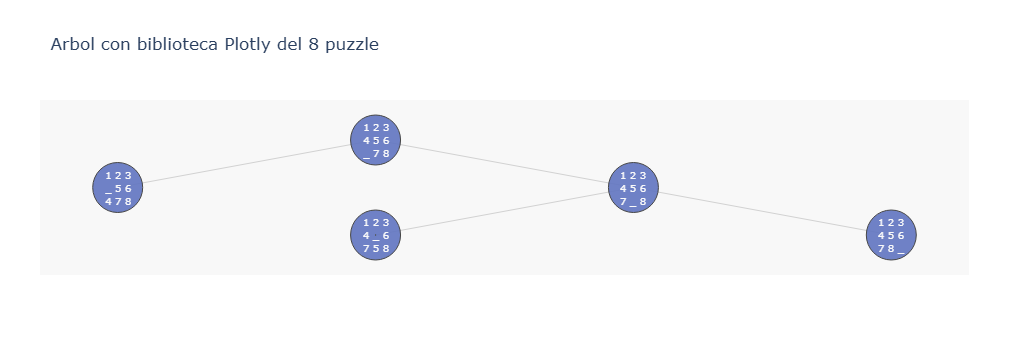

In [128]:
inicio = [
    [1, 2, 3],
    [4, 5, 6],
    ["_", 7, 8]
]

meta = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, "_"]
]
nodo_inicio = Nodo(inicio)
camino = nodo_inicio.bpp(meta)
imprime_camino(camino)

todos = construir_arbol(inicio, meta)
print("Nodos en arbol: " + str(len(todos)))
graficar(todos)